# KNN Classifier
## Handwritten digit recognition
In this notebook, we will use the built-in library ``sklearn`` to use KNN classifier.

## The MNIST dataset
`MNIST` is a classic dataset in machine learning, consisting of 28x28 gray-scale images handwritten digits. The training set contains 60,000 examples and the test set contains 10,000 examples. In this assignment we will further split the training set to take out 12,000 examples as a validation step.

In [1]:
%matplotlib inline
import gzip, os
import numpy as np
import matplotlib.pyplot as plt
import time
from urllib.request import urlretrieve, urlopen
from urllib.error import URLError, HTTPError

In [2]:
# Prefer stable HTTPS mirrors first
_MNIST_MIRRORS = [
    "https://storage.googleapis.com/cvdf-datasets/mnist/",
    "https://ossci-datasets.s3.amazonaws.com/mnist/",
    "http://yann.lecun.com/exdb/mnist/",  # fallback
]

# Function that downloads a specified MNIST data file from Yann Le Cun's website
def download(filename, mirrors=_MNIST_MIRRORS, chunk_size=1 << 20, timeout=30):
    """Download filename from the first working mirror."""
    if os.path.exists(filename) and os.path.getsize(filename) > 0:
        return filename

    last_err = None
    for base in mirrors:
        url = base + filename
        try:
            print(f"Downloading {filename} from {url}")
            with urlopen(url, timeout=timeout) as r, open(filename, "wb") as f:
                while True:
                    block = r.read(chunk_size)
                    if not block:
                        break
                    f.write(block)
            if os.path.getsize(filename) == 0:
                raise IOError("Downloaded empty file.")
            return filename
        except Exception as e:
            last_err = e
            print(f"  failed: {e}")
            if os.path.exists(filename):
                try: os.remove(filename)
                except OSError: pass

    raise RuntimeError(f"Could not download {filename} from any mirror.") from last_err

# Invokes download() if necessary, then reads in images
def load_mnist_images(filename):
    if not os.path.exists(filename):
        download(filename)
    with gzip.open(filename, 'rb') as f:
        data = np.frombuffer(f.read(), np.uint8, offset=16)
    return data.reshape(-1, 784)  # flat 28x28 → vector


def load_mnist_labels(filename):
    if not os.path.exists(filename):
        download(filename)
    with gzip.open(filename, 'rb') as f:
        data = np.frombuffer(f.read(), np.uint8, offset=8)
    return data

In [3]:
## Load the training set
train_data = load_mnist_images('train-images-idx3-ubyte.gz')
train_labels = load_mnist_labels('train-labels-idx1-ubyte.gz')

## Load the testing set
test_data = load_mnist_images('t10k-images-idx3-ubyte.gz')
test_labels = load_mnist_labels('t10k-labels-idx1-ubyte.gz')

In [4]:
## Print out their dimensions
print("Training dataset dimensions: ", np.shape(train_data))
print("Number of training labels: ", len(train_labels))
print("Testing dataset dimensions: ", np.shape(test_data))
print("Number of testing labels: ", len(test_labels))

Training dataset dimensions:  (60000, 784)
Number of training labels:  60000
Testing dataset dimensions:  (10000, 784)
Number of testing labels:  10000


In [5]:
## Compute the number of examples of each digit
train_digits, train_counts = np.unique(train_labels, return_counts=True)
print("Training set distribution:")
print(dict(zip(train_digits, train_counts)))

test_digits, test_counts = np.unique(test_labels, return_counts=True)
print("Test set distribution:")
print(dict(zip(test_digits, test_counts)))

Training set distribution:
{np.uint8(0): np.int64(5923), np.uint8(1): np.int64(6742), np.uint8(2): np.int64(5958), np.uint8(3): np.int64(6131), np.uint8(4): np.int64(5842), np.uint8(5): np.int64(5421), np.uint8(6): np.int64(5918), np.uint8(7): np.int64(6265), np.uint8(8): np.int64(5851), np.uint8(9): np.int64(5949)}
Test set distribution:
{np.uint8(0): np.int64(980), np.uint8(1): np.int64(1135), np.uint8(2): np.int64(1032), np.uint8(3): np.int64(1010), np.uint8(4): np.int64(982), np.uint8(5): np.int64(892), np.uint8(6): np.int64(958), np.uint8(7): np.int64(1028), np.uint8(8): np.int64(974), np.uint8(9): np.int64(1009)}


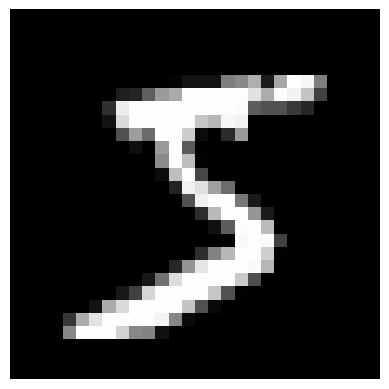

Label 5


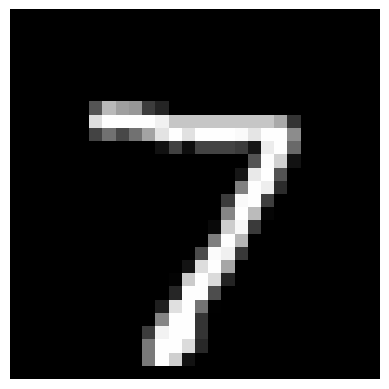

Label 7


In [6]:
## Define a function that displays a digit given its vector representation
def show_digit(x):
    plt.axis('off')
    plt.imshow(x.reshape((28,28)), cmap=plt.cm.gray)
    plt.show()
    return

## Define a function that takes an index into a particular data set ("train" or "test") and displays that image.
def vis_image(index, dataset="train"):
    if(dataset=="train"): 
        show_digit(train_data[index,])
        label = train_labels[index]
    else:
        show_digit(test_data[index,])
        label = test_labels[index]
    print("Label " + str(label))
    return

## View the first data point in the training set
vis_image(0, "train")

## Now view the first data point in the test set
vis_image(0, "test")

## Splitting the Train data to Train and Validate Sets

In [7]:
from sklearn.model_selection import train_test_split
trainx, valx, trainy, valy = train_test_split(train_data, train_labels, test_size=0.20, random_state=42)

## 1. K-Nearest neighbor classifier--Brute Force Approach

Here will be using the built-in KNN classifier to perform handwritten digit classification task. The hyper-parameter selection shall be performed on the independent validation set and not on the test set. A study needed for the KNeighborsClassifier documentation to understand how to use the api with different parameters. In this set of experiments, we need to select 'brute' for the **algorithm** parameter. Record the error rates on the test set and the cpu time taken for evaluation.

**Note:** Here we don't have to implement the KNN classifier but you just need to use it from ``sklearn`` library.

In [ ]:
from sklearn.neighbors import KNeighborsClassifier

### 1. Picking the best k using the validation set ###

k_values = [1,3,5,7,9,11,13,15,17] # KNN is expensive, so we will keep the k range small (and odd for breaking-ties), and for image data like MNIST, useful k values are typically small.
# Also, as we will see later, as we increase k, the accuracy will increase.
best_k = None 
best_validation_accuracy = float("-inf")

for k in k_values:
    KNN_model = KNeighborsClassifier(n_neighbors = k, algorithm = 'brute', metric = 'euclidean', weights = 'uniform', n_jobs = -1)
    KNN_model.fit(trainx, trainy)
    validation_accuracy = KNN_model.score(valx, valy)
    print("k = %-2d | Validation Accuracy = %.2f%%" % (k, validation_accuracy * 100))

    if validation_accuracy > best_validation_accuracy:
        best_validation_accuracy = validation_accuracy
        best_k = k

print()
print("Best k on validation is = %-2d, with accuracy = %.2f%%" % (best_k, best_validation_accuracy * 100))
print()

### 2. Do retraining on train and validation sets with the best k ###
X_final = np.concatenate((trainx, valx), axis=0)
y_final = np.concatenate((trainy, valy), axis=0) 
KNN_model = KNeighborsClassifier(n_neighbors = best_k, algorithm = 'brute', metric = 'euclidean', weights = 'uniform', n_jobs = -1)
KNN_model.fit(X_final, y_final) 

#### 3. Do Evaluate test performance: accuracy, error, CPU time ###

initial_time = time.time()
test_accuracy = KNN_model.score(test_data, test_labels)
prediction_time = time.time() - initial_time
test_error = 1.0 - test_accuracy

print("Test Accuracy: %.2f%%" % (test_accuracy * 100))
print("Test Error: %.2f%%" % (test_error * 100))
print("Evaluation CPU time for test set: %.2fs" % (prediction_time))




k = 1  | Validation Accuracy = 97.41%
k = 3  | Validation Accuracy = 97.27%
k = 5  | Validation Accuracy = 97.15%
k = 7  | Validation Accuracy = 96.96%
k = 9  | Validation Accuracy = 96.73%
k = 11 | Validation Accuracy = 96.51%
k = 13 | Validation Accuracy = 96.43%
k = 15 | Validation Accuracy = 96.36%
k = 17 | Validation Accuracy = 96.15%

Best k on validation is = 1 , with accuracy = 97.41%

Test Accuracy: 96.91%
Test Error: 3.09%
Evaluation CPU time for test set: 9.39s


## 2. Faster nearest neighbor methods

Performing nearest neighbor classification in the way we have presented requires a full pass through the training set in order to classify a single point. If there are $N$ training points in $\mathbb{R}^d$, this takes $O(N d)$ time.

Fortunately, there are faster methods to perform nearest neighbor look up if we are willing to spend some time preprocessing the training set. `scikit-learn` has fast implementations of two useful nearest neighbor data structures: the _ball tree_ and the _k-d tree_. Record the error rates on the test set and the cpu time taken for evaluation using these two faster methods.

**Note:** We need to select 'ball_tree'or 'kd_tree' for the **algorithm** parameter for ``KNeighborsClassifier`` classifier.

In [ ]:
# I can use KNeighborsClassifier with correct values for 'algorithm'

### 1. Define a helper function that will take algorithm name as parameter (instead of duplicate code), and do fit + record: accuracy, error rates, cpu time

def fit_and_time(algorithm_name):

    ### 1.1 build classifier with the chosen algorithm
    KNN_model = KNeighborsClassifier(n_neighbors=best_k, algorithm=algorithm_name, metric='euclidean', weights='uniform', n_jobs=-1)

    ### 1.2 fit (tree building happens here for kd/ball)
    KNN_model.fit(X_final, y_final)

    ### 1.3 time ONLY the evaluation step on test set
    initial_time = time.time()
    test_accuracy = KNN_model.score(test_data, test_labels)
    prediction_time = time.time() - initial_time

    test_error = 1.0 - test_accuracy

    print("%s -> Test Accuracy: %.2f | Test Error: %.2f | Evaluation CPU time: %.3fs" % (algorithm_name, test_accuracy * 100, test_error * 100, prediction_time))
    return test_accuracy, prediction_time

### 2. Run KNN with both approaches: kd_trees and ball_trees

kd_accuracy, kd_time = fit_and_time('kd_tree')
ball_accuracy, ball_time = fit_and_time('ball_tree')



kd_tree -> Test Accuracy: 96.91 | Test Error: 3.09 | Evaluation CPU time: 46.701s
ball_tree -> Test Accuracy: 96.91 | Test Error: 3.09 | Evaluation CPU time: 46.400s


## 3. Record CPU time and accuracy for all the three approaches in different datasets

Here I will use brute-force, kd-tree, and ball-tree approaches for the following datasets and record the accuracies and cpu time (for evaluation step only). Looking at the results, can we explain it.

Datasets:
1. Abalone Data Set (https://archive.ics.uci.edu/ml/datasets/abalone)
2. Statlog (Landsat Satellite) Data Set (https://archive.ics.uci.edu/ml/datasets/Statlog+(Landsat+Satellite))

**Note:** The datasets are provided as attachement in the assignment as CSV files.

**Hint:** The Abalone dataset contains a categorical feature, so you need to apply one-hot encoding in the preprocessing step.

In [ ]:
# We can use KNeighborsClassifier with correct values for 'algorithm'
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.neighbors import KNeighborsClassifier

###### Abalone part #####

### 1. Reading the Abalone dataset (and also adding the headers since they're orignially omitted) 
colnames = [
    "Sex", "Length", "Diameter", "Height",
    "WholeWeight", "ShuckedWeight", "VisceraWeight", "ShellWeight", "Rings"
]
abalone = pd.read_csv("Abalone19.csv", header=None, names = colnames)

#Abalone19 setup: make a rare positive class (Rings ≥ 19) to turn the original regression into an imbalanced binary task.
y_ab = (abalone["Rings"] >= 19).astype(int) 
X_ab = abalone.drop(columns=["Rings"])

### 2. Preprocessing the dataset: Applying one-hot for "Sex" and numerical scale
X_ab = pd.get_dummies(X_ab, columns=["Sex"])

### 3. Data splitting -> 60/20/20 (stratified)
train_data, test_data, train_labels, test_labels = train_test_split(X_ab, y_ab, test_size=0.20, stratify=y_ab, random_state=42)
trainx, valx, trainy, valy = train_test_split(train_data, train_labels, test_size=0.20, stratify=train_labels, random_state=42)

### 4. Feature Scaling
scaler_ab = StandardScaler()
trainx = scaler_ab.fit_transform(trainx)
valx = scaler_ab.transform(valx)
test_data = scaler_ab.transform(test_data)


### 5. Pick k on validation (brute)
k_values = [1,3,5,7,9,11,13,15,17]
best_k = None 
best_validation_accuracy = float("-inf")

for k in k_values:
    KNN_model = KNeighborsClassifier(n_neighbors=k, algorithm='brute', metric='euclidean', weights='uniform', n_jobs=-1)
    KNN_model.fit(trainx, trainy)
    validation_accuracy = KNN_model.score(valx, valy)
    print("k = %-2d | Validation Accuracy = %.2f%%" % (k, validation_accuracy * 100))
    if validation_accuracy > best_validation_accuracy:
        best_validation_accuracy = validation_accuracy
        best_k = k

print()
print("\nBest k on validation (Abalone) = %-2d, with accuracy = %.2f%%\n" % (best_k, best_validation_accuracy * 100))

### 6. Retrain on train and validation sets, then evaluate on test for each algorithm (time evaluation only)
X_final = np.vstack([trainx, valx])
y_final = np.concatenate([trainy, valy])

for algorithm in ["brute", "kd_tree", "ball_tree"]:
    KNN_model = KNeighborsClassifier(n_neighbors = best_k, algorithm = algorithm, metric='euclidean', weights='uniform', n_jobs=-1)
    KNN_model.fit(X_final, y_final)

    initial_time = time.time()
    test_accuracy = KNN_model.score(test_data, test_labels)
    prediction_time = time.time() - initial_time
    test_error = 1.0 - test_accuracy

    print("%9s -> Test Accuracy: %.2f%% | Test Error: %.2f%% | Evaluation CPU Time: %.3fs"% (algorithm, test_accuracy * 100, test_error * 100, prediction_time))



k = 1  | Validation Accuracy = 96.11%
k = 3  | Validation Accuracy = 97.91%
k = 5  | Validation Accuracy = 97.61%
k = 7  | Validation Accuracy = 97.76%
k = 9  | Validation Accuracy = 97.76%
k = 11 | Validation Accuracy = 97.76%
k = 13 | Validation Accuracy = 97.76%
k = 15 | Validation Accuracy = 97.76%
k = 17 | Validation Accuracy = 97.76%


Best k on validation (Abalone) = 3 , with accuracy = 97.91%

    brute -> Test Accuracy: 97.25% | Test Error: 2.75% | Evaluation CPU Time: 0.003s
  kd_tree -> Test Accuracy: 97.25% | Test Error: 2.75% | Evaluation CPU Time: 0.015s
ball_tree -> Test Accuracy: 97.25% | Test Error: 2.75% | Evaluation CPU Time: 0.014s


In [12]:
###### Statlog (Landsat Satellite) part #####

### 1. Reading the Statlog dataset
satimage = pd.read_csv("186_satimage.csv")

 
y_sat = satimage.iloc[:, -1].astype(int)
X_sat = satimage.iloc[:, :-1]

### 2. Data splitting -> 60/20/20 (stratified)
train_data, test_data, train_labels, test_labels = train_test_split(
    X_sat, y_sat, test_size=0.20, stratify=y_sat, random_state=42
)
trainx, valx, trainy, valy = train_test_split(
    train_data, train_labels, test_size=0.20, stratify=train_labels, random_state=42
)

### 3. Feature Scaling
scaler_sat = StandardScaler()
trainx    = scaler_sat.fit_transform(trainx)
valx      = scaler_sat.transform(valx)
test_data = scaler_sat.transform(test_data)

### 4. Pick k on validation (brute)
k_values = [1,3,5,7,9,11,13,15,17]
best_k = None
best_validation_accuracy = float("-inf")

for k in k_values:
    KNN_model = KNeighborsClassifier(n_neighbors=k, algorithm='brute',
                                     metric='euclidean', weights='uniform', n_jobs=-1)
    KNN_model.fit(trainx, trainy)
    validation_accuracy = KNN_model.score(valx, valy)
    print("k = %-2d | Validation Accuracy = %.2f%%" % (k, validation_accuracy * 100))
    if validation_accuracy > best_validation_accuracy:
        best_validation_accuracy = validation_accuracy
        best_k = k

print()
print("\nBest k on validation (Satimage) = %-2d, acc = %.2f%%\n" % (best_k, best_validation_accuracy * 100))

### 5. Retrain on train and validation sets, then evaluate on test for each algorithm (time evaluation only)
X_final = np.vstack([trainx, valx])
y_final = np.concatenate([trainy, valy])

for algorithm in ["brute", "kd_tree", "ball_tree"]:
    KNN_model = KNeighborsClassifier(n_neighbors=best_k, algorithm=algorithm,
                                     metric='euclidean', weights='uniform', n_jobs=-1)
    KNN_model.fit(X_final, y_final)

    initial_time = time.time()
    test_accuracy = KNN_model.score(test_data, test_labels)
    prediction_time = time.time() - initial_time
    test_error = 1.0 - test_accuracy

    print("%9s -> Test Accuracy: %.2f%% | Test Error: %.2f%% | Evaluation CPU Time: %.3fs"
          % (algorithm, test_accuracy * 100, test_error * 100, prediction_time))



k = 1  | Validation Accuracy = 89.80%
k = 3  | Validation Accuracy = 91.35%
k = 5  | Validation Accuracy = 91.35%
k = 7  | Validation Accuracy = 91.45%
k = 9  | Validation Accuracy = 90.67%
k = 11 | Validation Accuracy = 90.18%
k = 13 | Validation Accuracy = 90.38%
k = 15 | Validation Accuracy = 89.60%
k = 17 | Validation Accuracy = 89.89%


Best k on validation (Satimage) = 7 , acc = 91.45%

    brute -> Test Accuracy: 89.42% | Test Error: 10.58% | Evaluation CPU Time: 0.007s
  kd_tree -> Test Accuracy: 89.42% | Test Error: 10.58% | Evaluation CPU Time: 0.015s
ball_tree -> Test Accuracy: 89.42% | Test Error: 10.58% | Evaluation CPU Time: 0.014s


In [13]:
### Explanation

print("On Abalone19, k=3 worked best (97.91%) because a tiny, odd k sticks to the local patterns without averaging them away—once I push k higher, the decision gets too smoothed and accuracy plateaus. The three methods (brute, kd-tree, ball-tree) all return the same neighbors with the same metric, so the test accuracy ends up identical (97.25%). The only difference is speed: brute is quickest (~0.003s vs ~0.015s) since the dataset is small and about 11-D, so a straight vectorized distance calc beats the extra tree build/traversal overhead.")


On Abalone19, k=3 worked best (97.91%) because a tiny, odd k sticks to the local patterns without averaging them away—once I push k higher, the decision gets too smoothed and accuracy plateaus. The three methods (brute, kd-tree, ball-tree) all return the same neighbors with the same metric, so the test accuracy ends up identical (97.25%). The only difference is speed: brute is quickest (~0.003s vs ~0.015s) since the dataset is small and about 11-D, so a straight vectorized distance calc beats the extra tree build/traversal overhead.


## E1. Extra Stuff

## Points to remember

We need to keep in mind the following points:
1. Using numpy arrays and numpy libraries for efficient computations. 

In [16]:
import numpy as np, time
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier

### As extra, I will do hand-crafted features

### Features: mean intensity, horizontal asymmetry, vertical asymmetry,
### centroid (cx, cy), and 4 quadrant means. Keep it small & interpretable.

def make_simple_features(X):
    n, d = X.shape
    side = int(np.sqrt(d))
    assert side * side == d, "Expected square images"
    imgs = X.reshape(n, side, side)

    # mean intensity
    mean_intensity = imgs.mean(axis=(1, 2))

    # horizontal / vertical asymmetry (avg absolute difference)
    left  = imgs[:, :, : side // 2]
    right = np.flip(imgs[:, :, - (side // 2):], axis=2)
    horiz_asym = np.mean(np.abs(left - right), axis=(1, 2))

    top    = imgs[:, : side // 2, :]
    bottom = np.flip(imgs[:, - (side // 2):, :], axis=1)
    vert_asym = np.mean(np.abs(top - bottom), axis=(1, 2))

    # centroid (weighted by intensity)
    rows = np.arange(side)[:, None]
    cols = np.arange(side)[None, :]
    mass = imgs.sum(axis=(1, 2)) + 1e-8
    cx = (imgs * cols).sum(axis=(1, 2)) / mass
    cy = (imgs * rows).sum(axis=(1, 2)) / mass

    # quadrant means
    q1 = imgs[:, : side // 2, : side // 2].mean(axis=(1, 2))
    q2 = imgs[:, : side // 2,   side // 2 :].mean(axis=(1, 2))
    q3 = imgs[:,   side // 2 :, : side // 2].mean(axis=(1, 2))
    q4 = imgs[:,   side // 2 :,   side // 2 :].mean(axis=(1, 2))

    feats = np.stack([mean_intensity, horiz_asym, vert_asym, cx, cy, q1, q2, q3, q4], axis=1)
    return feats

### 2. Compute features for train / validation / test and scale them
trainx_feat = make_simple_features(trainx)
valx_feat   = make_simple_features(valx)
testx_feat  = make_simple_features(test_data)

scaler_feat = StandardScaler()
trainx_feat = scaler_feat.fit_transform(trainx_feat)
valx_feat   = scaler_feat.transform(valx_feat)
testx_feat  = scaler_feat.transform(testx_feat)

### 3. Pick k on validation (using brute, same style as before)
k_values = [1,3,5,7,9,11]
best_k = None
best_validation_accuracy = float("-inf")

for k in k_values:
    KNN_model = KNeighborsClassifier(n_neighbors=k, algorithm='brute',
                                     metric='euclidean', weights='uniform', n_jobs=-1)
    KNN_model.fit(trainx_feat, trainy)
    validation_accuracy = KNN_model.score(valx_feat, valy)
    print("k = %-2d | Validation Accuracy (features) = %.2f%%" % (k, validation_accuracy * 100))
    if validation_accuracy > best_validation_accuracy:
        best_validation_accuracy = validation_accuracy
        best_k = k

print("\nBest k on validation (features) = %-2d, with accuracy = %.2f%%\n" % (best_k, best_validation_accuracy * 100))

### 4. Retrain on train+val features and evaluate on test for each algorithm (time evaluation only)
X_final_feat = np.vstack([trainx_feat, valx_feat])
y_final_feat = np.concatenate([trainy, valy])

for algorithm in ["brute", "kd_tree", "ball_tree"]:
    KNN_model = KNeighborsClassifier(n_neighbors=best_k, algorithm=algorithm,
                                     metric='euclidean', weights='uniform', n_jobs=-1)
    KNN_model.fit(X_final_feat, y_final_feat)

    start = time.time()
    test_accuracy = KNN_model.score(testx_feat, test_labels)
    eval_time = time.time() - start
    test_error = 1.0 - test_accuracy

    print("%9s -> Test Accuracy (features): %.2f%% | Test Error: %.2f%% | Evaluation CPU Time: %.3fs"
          % (algorithm, test_accuracy * 100, test_error * 100, eval_time))

k = 1  | Validation Accuracy (features) = 82.99%
k = 3  | Validation Accuracy (features) = 84.84%
k = 5  | Validation Accuracy (features) = 86.30%
k = 7  | Validation Accuracy (features) = 85.03%
k = 9  | Validation Accuracy (features) = 85.52%
k = 11 | Validation Accuracy (features) = 85.03%

Best k on validation (features) = 5 , with accuracy = 86.30%

    brute -> Test Accuracy (features): 85.07% | Test Error: 14.93% | Evaluation CPU Time: 0.005s
  kd_tree -> Test Accuracy (features): 85.07% | Test Error: 14.93% | Evaluation CPU Time: 0.015s
ball_tree -> Test Accuracy (features): 85.07% | Test Error: 14.93% | Evaluation CPU Time: 0.014s
